# Overtraining and Injury: Predicting Athlete Injury Risk from Performance and Training Data 

In [1]:
#Import necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Utilizing 4 distinct data sets we'll answer three things: 
#How common are overtraining related problems? 
#Are training variables able to predict injury
#Is it possible to predict these overtrainig related injuries?

In [3]:
#Upload the data sets containing subjects information
df_1 = pd.read_csv("High_Accuracy_Sport_Injury_Dataset.csv")
df_2 = pd.read_csv("run_data_meta.csv")
df_3 = pd.read_csv("walk_data_meta.csv")
df_4 = pd.read_csv("wlinj_dryad.csv") 

### Cleaning the Data: 

In [4]:
#Now we clean the data by droping columns that have to many empty or NaN values in it
nan_percent2 = df_2.isnull().mean() * 100
nan_percent3 = df_3.isnull().mean() * 100
nan_percent4 = df_4.isnull().mean() * 100
print("df_2: \n", nan_percent2, '\n')
print("df_3: \n", nan_percent3, '\n')
print("df_4: \n", nan_percent4, '\n')

df_2: 
 sub_id           0.000000
datestring       0.000000
filename         0.000000
speed_r          0.000000
age              0.000000
Height           0.163755
Weight           0.109170
Gender           0.000000
DominantLeg     19.213974
InjDefn          4.366812
InjJoint        12.772926
InjSide         26.528384
SpecInjury      32.150655
InjDuration     77.893013
InjJoint2       54.366812
InjSide2        55.131004
SpecInjury2     82.532751
Activities      17.248908
Level           14.683406
YrsRunning      28.220524
RaceDistance    18.449782
RaceTimeHrs     46.561135
RaceTimeMins    44.050218
RaceTimeSecs    49.563319
YrPR            76.801310
NumRaces        72.489083
dtype: float64 

df_3: 
 sub_id           0.000000
datestring       0.000000
filename         0.000000
speed_w          0.000000
age              0.000000
Height           3.017241
Weight           1.580460
Gender           0.000000
DominantLeg     31.513410
InjDefn         20.785441
InjJoint        11.015326
InjSi

In [5]:
#Now that we have the percentage of values in colums that are misssing we can procede to drop them
#I've decide to drop colums with over 40 percent where the value are missing or NaN
threshold = 0.40  

df_2 = df_2.loc[:, df_2.isnull().mean() < threshold]
df_3 = df_3.loc[:, df_3.isnull().mean() < threshold]

In [6]:
#Now we handle remaining NaN values by filling with 0 or labeling them as unknown
numeric_cols2 = df_2.select_dtypes(include=['number']).columns
categorical_cols2 = df_2.select_dtypes(exclude=['number']).columns

df_2[numeric_cols2] = df_2[numeric_cols2].fillna(0)
df_2[categorical_cols2] = df_2[categorical_cols2].fillna("Unknown")

numeric_cols3 = df_3.select_dtypes(include=['number']).columns
categorical_cols3 = df_3.select_dtypes(exclude=['number']).columns

df_3[numeric_cols3] = df_3[numeric_cols3].fillna(0)
df_3[categorical_cols3] = df_3[categorical_cols3].fillna("Unknown")

In [7]:
#We calculate the percentage again to verify once more
nan_percent2 = df_2.isnull().mean() * 100
nan_percent3 = df_3.isnull().mean() * 100
print("df_2: \n", nan_percent2, '\n')
print("df_3: \n", nan_percent3, '\n')

df_2: 
 sub_id          0.0
datestring      0.0
filename        0.0
speed_r         0.0
age             0.0
Height          0.0
Weight          0.0
Gender          0.0
DominantLeg     0.0
InjDefn         0.0
InjJoint        0.0
InjSide         0.0
SpecInjury      0.0
Activities      0.0
Level           0.0
YrsRunning      0.0
RaceDistance    0.0
dtype: float64 

df_3: 
 sub_id          0.0
datestring      0.0
filename        0.0
speed_w         0.0
age             0.0
Height          0.0
Weight          0.0
Gender          0.0
DominantLeg     0.0
InjDefn         0.0
InjJoint        0.0
InjSide         0.0
SpecInjury      0.0
Activities      0.0
Level           0.0
RaceDistance    0.0
dtype: float64 



### Creating a Prediction Model: 

In [8]:
#Import the necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display

In [9]:
#We copy the data set that will be used for the prediction model and then scale the copy so all values have the same weight
sdf = df_1.copy()

feature_cols = [col for col in sdf.columns if col != 'Injury_Risk']
scaler = MinMaxScaler()

sdf[feature_cols] = scaler.fit_transform(sdf[feature_cols])
display(sdf)

,Age,Gender,Height_cm,Weight_kg,BMI,Training_Frequency,Training_Duration,Warmup_Time,Sleep_Hours,Flexibility_Score,Muscle_Asymmetry,Recovery_Time,Injury_History,Stress_Level,Training_Intensity,Injury_Risk
0,0.818182,0.0,0.1350,0.226,0.511249,0.0,0.653333,1.00,0.488889,0.511700,0.256944,0.370787,0.333333,0.777778,0.377778,0
1,0.545455,0.0,0.4400,0.006,0.165629,0.6,0.920000,0.25,0.466667,0.531981,0.354167,0.382022,0.333333,0.666667,0.633333,0
2,0.136364,1.0,0.6675,0.316,0.326472,0.0,0.666667,0.55,0.000000,0.594384,0.423611,0.438202,0.000000,0.555556,0.366667,1
3,0.863636,0.0,0.5050,0.314,0.397798,0.8,0.373333,0.30,0.688889,0.600624,0.319444,0.393258,0.666667,0.222222,0.600000,1
4,0.545455,0.0,0.2875,0.000,0.219722,1.0,0.640000,0.40,0.622222,0.229329,0.590278,0.134831,1.000000,0.777778,0.355556,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,0.772727,0.0,0.4600,0.148,0.278124,0.0,0.866667,1.00,0.422222,0.313573,0.111111,0.696629,0.000000,1.000000,0.455556,0
596,0.727273,0.0,0.3600,0.244,0.407851,0.8,0.253333,0.20,0.511111,0.458658,0.291667,0.000000,0.000000,0.111111,0.633333,0
597,0.454545,0.0,0.1800,0.378,0.632360,0.8,0.746667,0.65,0.555556,0.360374,0.465278,0.191011,0.000000,0.777778,0.600000,0
598,0.681818,0.0,0.2075,0.594,0.820967,0.2,0.586667,0.80,0.644444,0.377535,0.145833,0.730337,0.666667,0.777778,0.433333,1


In [10]:
# Split full dataset
X = sdf.drop('Injury_Risk', axis=1)
y = sdf['Injury_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the model on the full dataset
clf = RandomForestClassifier(n_jobs=-1, random_state=42)
clf.fit(X_train, y_train)

# Predictions for confusion matrix
preds = clf.predict(X_test)

accuracy = accuracy_score(y_test, preds)
print("Accuracy:", round(accuracy, 2))

Accuracy: 0.97


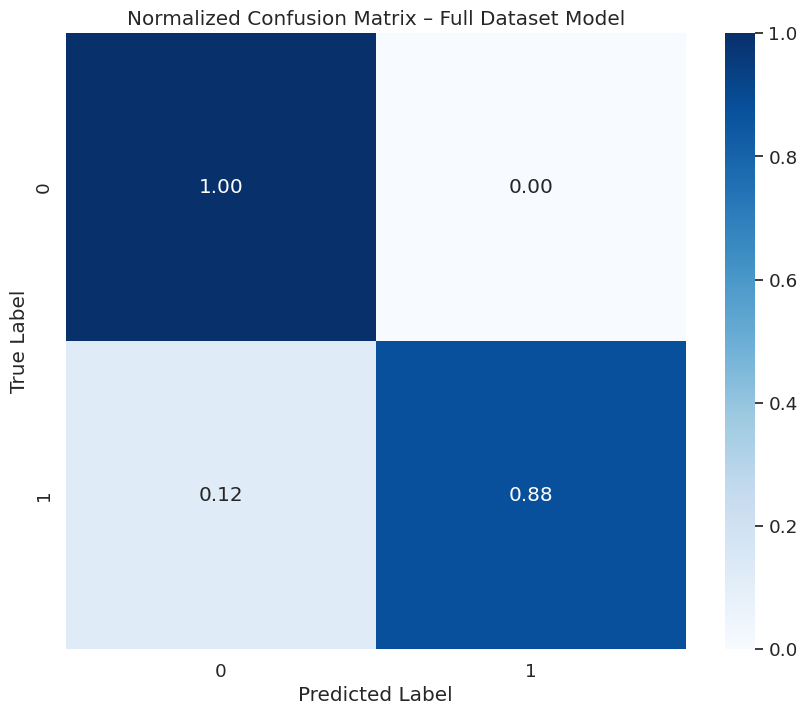

In [11]:
%matplotlib inline
import seaborn as sns

#We create a confusion matrix
cm = confusion_matrix(y_test, preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

injury_risk = sorted(y_test.unique())

plt.figure(figsize=(10, 8))
sns.set(font_scale=1.2)

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=injury_risk,
    yticklabels=injury_risk
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix – Full Dataset Model")
plt.show()

In [12]:
# Compute median age

median_age = sdf["Age"].median()
print("Median age:", median_age)

# Create two groups based on median
age_low = sdf[sdf["Age"] <= median_age]
age_high = sdf[sdf["Age"] > median_age]

#Function capable of creating prediction models based on age subgroups of the data set
def plot_feature_importance_group(df_group, title):
    if len(df_group) < 30:   # Minimum samples for stable model
        print(f"Not enough samples for: {title}")
        return
    
    # Build X and y
    X = df_group.drop(["Injury_Risk"], axis=1)
    y = df_group["Injury_Risk"]
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Train RF
    clf = RandomForestClassifier(n_jobs=-1, random_state=42)
    clf.fit(X_train, y_train)

    # Prediction acurracy
    preds = clf.predict(X_test)
    
    # Importances
    feature_names = np.array(X.columns)
    
    # Optional: remove Injury_History to highlight other variables
    mask = feature_names != "Injury_History"
    feature_names = feature_names[mask]
    importances = clf.feature_importances_[mask]
    
    # Sort
    N = 7
    indices = np.argsort(importances)[::-1][:N]
    
    # Plot
    color = "red" if "≤" in title else "skyblue"
    plt.figure(figsize=(8, 6))
    plt.barh(feature_names[indices], importances[indices], color=color)
    plt.xlabel("Feature Importance Score")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.show()
    accuracy = accuracy_score(y_test, preds)
    print("Accuracy:", round(accuracy, 2))

Median age: 0.4999999999999999


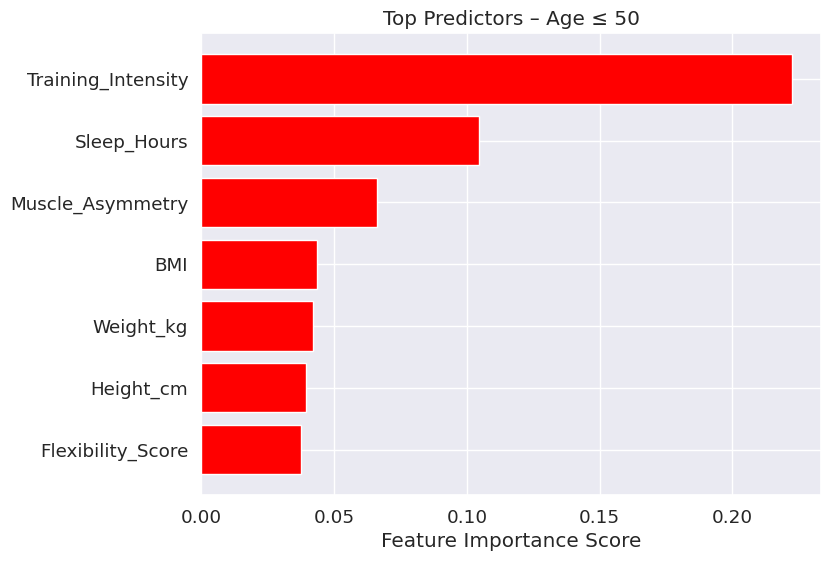

Accuracy: 0.89


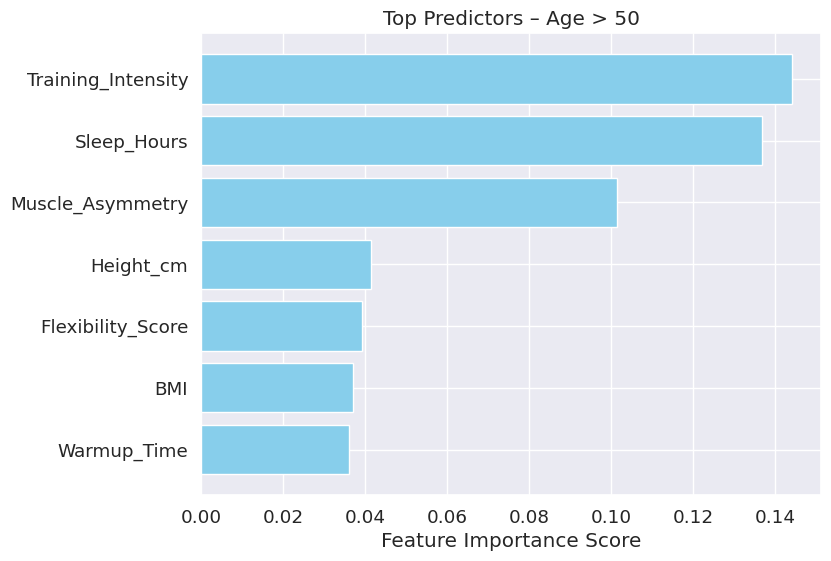

Accuracy: 0.95


In [13]:
plot_feature_importance_group(age_low,  f"Top Predictors – Age ≤ {round(median_age * 100)}")
plot_feature_importance_group(age_high, f"Top Predictors – Age > {round(median_age * 100)}")

### Performing Data Analysis on Various Data Sets: 

In [15]:
#Lets view column variables
print(df_2.columns)
print(df_3.columns)
print(df_4.columns)

Index(['sub_id', 'datestring', 'filename', 'speed_r', 'age', 'Height',
       'Weight', 'Gender', 'DominantLeg', 'InjDefn', 'InjJoint', 'InjSide',
       'SpecInjury', 'Activities', 'Level', 'YrsRunning', 'RaceDistance'],
      dtype='object')
Index(['sub_id', 'datestring', 'filename', 'speed_w', 'age', 'Height',
       'Weight', 'Gender', 'DominantLeg', 'InjDefn', 'InjJoint', 'InjSide',
       'SpecInjury', 'Activities', 'Level', 'RaceDistance'],
      dtype='object')
Index(['id', 'sex', 'age', 'agegrp3', 'age_start', 'yrs_experience',
       'shoulder', 'knees', 'back', 'wrist', 'hips', 'OA', 'train_days',
       'train_session', 'train_warm', 'train_lift', 'train_strength',
       'train_supp', 'train_cool', 'pcoach', 'premote', 'pown', 'nutrition',
       'pa_power', 'pa_body', 'pa_cf', 'pa_ball', 'pa_fit', 'pa_endure',
       'pa_track', 'pa_ma', 'pa_yoga', 'sport0_power', 'sport0_body',
       'sport0_cf', 'sport0_ball', 'sport0_fit', 'sport0_endure',
       'sport0_track', 'spor

In [16]:
df_2.loc[df_2['InjJoint'] == "No injury,No injury", 'InjJoint'] = "No Injury"
df_2['InjJoint'].value_counts()

InjJoint
No Injury           417
Knee                348
Unknown             234
Lower Leg           185
Thigh               181
Foot                141
Hip/Pelvis          136
Ankle               107
Lumbar Spine         41
Sacroiliac Joint     22
Other                20
Name: count, dtype: int64

In [17]:
df_2['InjJoint'].value_counts(normalize=True) * 100

InjJoint
No Injury           22.762009
Knee                18.995633
Unknown             12.772926
Lower Leg           10.098253
Thigh                9.879913
Foot                 7.696507
Hip/Pelvis           7.423581
Ankle                5.840611
Lumbar Spine         2.237991
Sacroiliac Joint     1.200873
Other                1.091703
Name: proportion, dtype: float64

In [18]:
injury_df = df_2[~df_2['InjJoint'].isin(["No Injury", "Unknown"])]
run_injury_rate = injury_df.shape[0] / df_2.shape[0] * 100
print(round(run_injury_rate, 2), "% of runners reported an injury/joint issue.")

64.47 % of runners reported an injury/joint issue.


In [19]:
df_3.loc[df_3['InjJoint'] == "No injury,No injury", 'InjJoint'] = "No Injury"

df_3['InjJoint'].value_counts()

InjJoint
Knee                659
No Injury           346
Unknown             230
Lower Leg           157
Thigh               145
Hip/Pelvis          136
Foot                133
Ankle               101
Hip                  87
Lumbar Spine         45
Other                25
Sacroiliac Joint     24
Name: count, dtype: int64

In [20]:
df_3['InjJoint'].value_counts(normalize=True) * 100

InjJoint
Knee                31.561303
No Injury           16.570881
Unknown             11.015326
Lower Leg            7.519157
Thigh                6.944444
Hip/Pelvis           6.513410
Foot                 6.369732
Ankle                4.837165
Hip                  4.166667
Lumbar Spine         2.155172
Other                1.197318
Sacroiliac Joint     1.149425
Name: proportion, dtype: float64

In [21]:
injury_df = df_3[~df_3['InjJoint'].isin(["No Injury", "Unknown"])]
walk_injury_rate = injury_df.shape[0] / df_3.shape[0] * 100
print(round(walk_injury_rate, 2), "% of walkers reported an injury/joint issue.")

72.41 % of walkers reported an injury/joint issue.


In [22]:
pd.set_option('future.no_silent_downcasting', True)
df_4['hips'] = df_4['hips'].replace({"yes": 1, "no": 0})
df_4[['shoulder','knees','back','wrist','hips']].sum()

shoulder    343
knees       258
back        229
wrist       211
hips        123
dtype: object

In [23]:
df_4[['shoulder','knees','back','wrist','hips']].mean() * 100

shoulder    35.143443
knees       26.434426
back        23.463115
wrist       21.618852
hips        12.602459
dtype: object

In [24]:
lift_injury_rate = df_4[['shoulder','knees','back','wrist','hips']].max(axis=1).mean() * 100

print(round(lift_injury_rate, 2), "% of lifters reported an injury/joint issue.")

64.14 % of lifters reported an injury/joint issue.


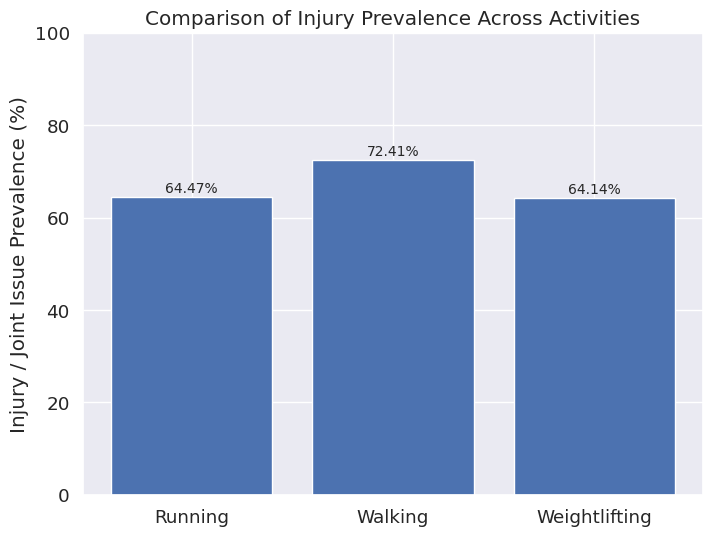

In [26]:
#Represent this percentages graphically
injury_rates = {
    "Running": run_injury_rate,
    "Walking": walk_injury_rate,
    "Weightlifting":  lift_injury_rate  # replace with your value
}

activities = list(injury_rates.keys())
values = list(injury_rates.values())

plt.figure(figsize=(8, 6))
bars = plt.bar(activities, values)

# Add labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1,
             f"{height:.2f}%", ha='center', fontsize=10)

plt.ylim(0, 100)
plt.ylabel("Injury / Joint Issue Prevalence (%)")
plt.title("Comparison of Injury Prevalence Across Activities")
plt.show()